## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
import qutip as qu

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

## 2 Level System

In [58]:
# Define the parameters
g = 2      # the coupling strength between the atom and the cavity field
κ = 1      # the cavity loss coefficient
γ = 1      # the atomic loss coefficient
J = 1e-4   # the strength of the coherent drive   

# Define the cavity and atom frequencies
ω32 = 5
ωL32 = 5

# Define the driving frequency range
ωd = np.linspace(-15, 25, 100)

# Define the annihilation operator for the cavity - we'll consider 2 fock states
N = 2
a = qu.tensor(qu.qeye(2), qu.destroy(N))

# Define the atomic lowering operator
σ = qu.tensor(qu.destroy(2), qu.qeye(N))

# Create list of collapse operators for the steady state solver
c_opt_list = [κ * a, γ * σ]

In [59]:
# Use the qutip steady state solver to calculate the expectation value of the cavity field
a_expt_list = []
σ_expt_list = []
for i in range(ωd.shape[0]):
    H = (ωL32 - ωd[i]) * a.dag() * a + ( ω32 - ωd[i]) * σ.dag() * σ + g * (a.dag() * σ + a * σ.dag()) + J * (a.dag() + a)
    rho_ss = qu.steadystate(H, c_opt_list)
    a_expt_list.append(np.abs(qu.expect(a, rho_ss)))
    σ_expt_list.append(np.abs(qu.expect(σ, rho_ss)))

In [60]:
H = ωL32 * a.dag() * a + ω32 * σ.dag() * σ + 2 * (a.dag() * σ + a * σ.dag())

In [61]:
test = np.array([[0, g], [g, 0]])
np.linalg.eigvalsh(test)

array([-2.,  2.])

In [62]:
H.eigenenergies()

array([ 0.,  3.,  7., 10.])

In [63]:
analytic_a = -1j * J * (γ / 2 + 1j * (ω32 - ωd)) / ((κ / 2 + 1j * (ωL32 - ωd)) * (γ / 2 + 1j * (ω32 - ωd)) + g ** 2)
analytic_σ = J * g / ((κ / 2 + 1j * (ωL32 - ωd)) * (γ / 2 + 1j * (ω32 - ωd)) + g ** 2)

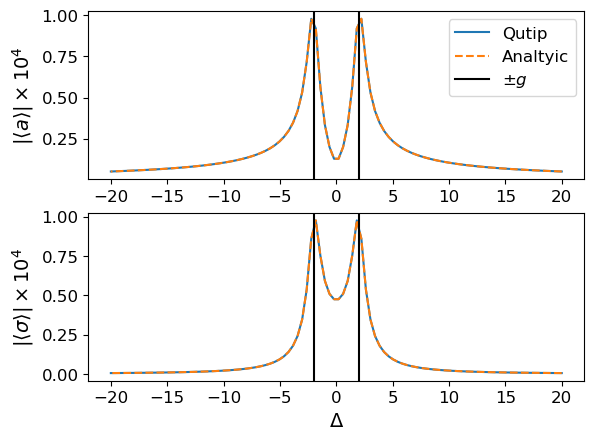

In [74]:
# Plot the expected values of the cavity field against the detuning
fig = plt.figure(1)
ax = fig.subplots(2, 1)
ax[0].plot(ωL32 - ωd, np.array(a_expt_list) * 1e4, label='Qutip')
ax[0].plot(ωL32 - ωd, np.abs(analytic_a) * 1e4, '--', label='Analtyic')
ax[0].axvline(x=-g, color='k', label='$\\pm g$')
ax[0].axvline(x=g, color='k')
#ax[0].set_xlabel("$\\Delta$")
ax[0].set_ylabel("$|\\langle a \\rangle| \\times 10^4$")
ax[0].legend()

ax[1].plot(ωL32 - ωd, np.array(σ_expt_list) * 1e4)
ax[1].plot(ωL32 - ωd, np.abs(analytic_σ) * 1e4, '--')
ax[1].axvline(x=-g, color='k')
ax[1].axvline(x=g, color='k')
ax[1].set_xlabel("$\\Delta$")
ax[1].set_ylabel("$|\\langle \\sigma \\rangle| \\times 10^4$")

fig.savefig("expt_vs_delta_2lvl.png", format='png', dpi=300)

## 3 Level System

In [112]:
# Define the parameters
g32 = 2      # the coupling strength between the atom and the cavity field
g21 = 3      # the coupling strength between the |1>-|2> transition and the classical field
κ = 1        # the cavity loss coefficient
γ32 = 1      # the atomic loss coefficient for the |2>-|3> transition
γ21 = 1      # the atomic loss coefficient for the |2>-|1> transition
J = 1e-4     # the strength of the coherent drive   

# Define the cavity and atom frequencies
ω32 = 5
ω21 = 2.5
ωL32 = 5
ωL21 = 2.5

# Define the driving frequency range
ωd = np.linspace(-15, 25, 100)

# Define the annihilation operator for the cavity - we'll consider 2 fock states
N = 2
a = qu.tensor(qu.qeye(3), qu.destroy(N))

# Define the atomic lowering operator
σ32 = qu.tensor(qu.Qobj([[0, 0, 0], [0, 0, 1], [0, 0, 0]]), qu.qeye(N))
σ21 = qu.tensor(qu.Qobj([[0, 1, 0], [0, 0, 0], [0, 0, 0]]), qu.qeye(N))

# Create list of collapse operators for the steady state solver
c_opt_list = [κ * a, γ32 * σ32, γ21 * σ21]

In [113]:
# Use the qutip steady state solver to calculate the expectation value of the cavity field
a_expt_list = []
σ32_expt_list = []
σ21_expt_list = []
σ31_expt_list = []
for i in range(ωd.shape[0]):
    H = (ωL32 - ωd[i]) * a.dag() * a + (ω32 - ωd[i]) * σ32.dag() * σ32 + g * (a.dag() * σ32 + a * σ32.dag()) + J * (a.dag() + a)
    H += (ω21 - ωd[i]) * σ21.dag() * σ21 + g21 * (σ21.dag() + σ21)
    rho_ss = qu.steadystate(H, c_opt_list)
    a_expt_list.append(np.abs(qu.expect(a, rho_ss)))
    σ32_expt_list.append(np.abs(qu.expect(σ32, rho_ss)))
    σ21_expt_list.append(np.abs(qu.expect(σ21, rho_ss)))

In [114]:
H = ωL32 * a.dag() * a + ω32 * σ32.dag() * σ32 + g32 * (a.dag() * σ32 + a * σ32.dag())
H += ω21 * σ21.dag() * σ21 + g21 * (σ21.dag() + σ21)

In [115]:
H.eigenenergies()

array([-2.        ,  2.43391562,  4.5       ,  5.        , 10.        ,
       10.06608438])

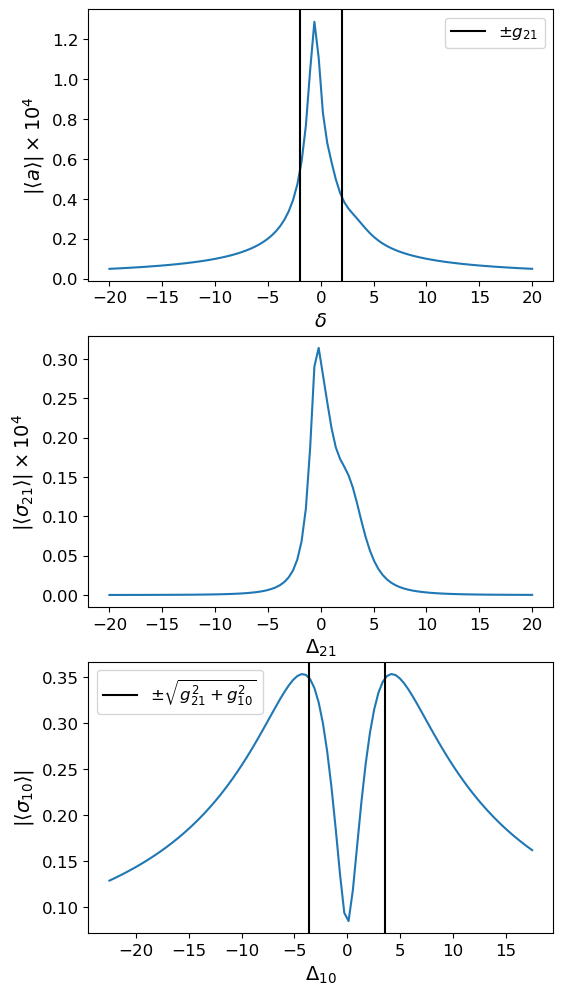

In [116]:
# Plot the expected values of the cavity field against the detuning
fig = plt.figure(1, figsize=(6, 12))
ax = fig.subplots(3,1)
ax[0].plot(ωL32 - ωd, np.array(a_expt_list) * 1e4)
ax[0].axvline(x=-g32, color='k', label='$\\pm g_{21}$')
ax[0].axvline(x=g32, color='k')
ax[0].set_xlabel("$\\delta$")
ax[0].set_ylabel("$|\\langle a \\rangle| \\times 10^4$")
ax[0].legend()
#plt.legend()

ax[1].plot(ω32 - ωd, np.array(σ32_expt_list) * 1e4)
ax[1].set_xlabel("$\\Delta_{21}$")
ax[1].set_ylabel("$|\\langle \\sigma_{21} \\rangle| \\times 10^4$")

ax[2].plot(ω21 - ωd, σ21_expt_list)
ax[2].axvline(x=-np.sqrt(g32 ** 2 + g21 ** 2), color='k', label='$\\pm \\sqrt{g_{21}^2 + g_{10}^2}$')
ax[2].axvline(x=np.sqrt(g32 ** 2 + g21 ** 2), color='k')
ax[2].set_xlabel("$\\Delta_{10}$")
ax[2].set_ylabel("$|\\langle \\sigma_{10} \\rangle|$")
ax[2].legend()
fig.savefig("expt_vals_vs_detuning_3lvl.png", format='png', dpi=300)

## 4 Level System

In [15]:
# Define the parameters
g32 = 2      # the coupling strength between the atom and the cavity field
g21 = 2      # the coupling strength between the |1>-|2> transition and the classical field
g10 = 2      # the coupling strength between the |0>-|1> transition and the second classical field
κ = 1        # the cavity loss coefficient
γ32 = 1     # the atomic loss coefficient for the |2>-|3> transition
γ21 = 1     # the atomic loss coefficient for the |2>-|1> transition
γ10 = 1     # the atomic loss coefficient for the |1>-|0> transition
J = 1e-4     # the strength of the coherent drive   

# Define the cavity and atom frequencies
ω32 = 5
ω21 = 2.5
ω10 = 1
ωL32 = 5
ωL21 = 2.5
ωL10 = 1

# Define the driving frequency range
ωd = np.linspace(-15, 25, 100)

# Define the annihilation operator for the cavity - we'll consider 2 fock states
N = 2
a = qu.tensor(qu.qeye(4), qu.destroy(N))

# Define the atomic lowering operator
σ32 = qu.tensor(qu.Qobj([[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 0, 0]]), qu.qeye(N))
σ21 = qu.tensor(qu.Qobj([[0, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 0], [0, 0, 0, 0]]), qu.qeye(N))
σ10 = qu.tensor(qu.Qobj([[0, 1, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]), qu.qeye(N))

# Create list of collapse operators for the steady state solver
c_opt_list = [κ * a, γ32 * σ32, γ21 * σ21, γ10 * σ10]

In [16]:
# Use the qutip steady state solver to calculate the expectation value of the cavity field
a_expt_list = []
σ32_expt_list = []
σ21_expt_list = []
σ10_expt_list = []
for i in range(ωd.shape[0]):
    H = (ωL32 - ωd[i]) * a.dag() * a + (ω32 - ωd[i]) * σ32.dag() * σ32 + g * (a.dag() * σ32 + a * σ32.dag()) + J * (a.dag() + a)
    H += (ω21 - ωd[i]) * σ21.dag() * σ21 + g21 * (σ21.dag() + σ21)
    H += (ω10 - ωd[i]) * σ10.dag() * σ10 + g10 * (σ10.dag() + σ10)
    rho_ss = qu.steadystate(H, c_opt_list)
    a_expt_list.append(np.abs(qu.expect(a, rho_ss)))
    σ32_expt_list.append(np.abs(qu.expect(σ32, rho_ss)))
    σ21_expt_list.append(np.abs(qu.expect(σ21, rho_ss)))
    σ10_expt_list.append(np.abs(qu.expect(σ10, rho_ss)))

Text(0, 0.5, '$\\langle \\sigma_{10} \\rangle$')

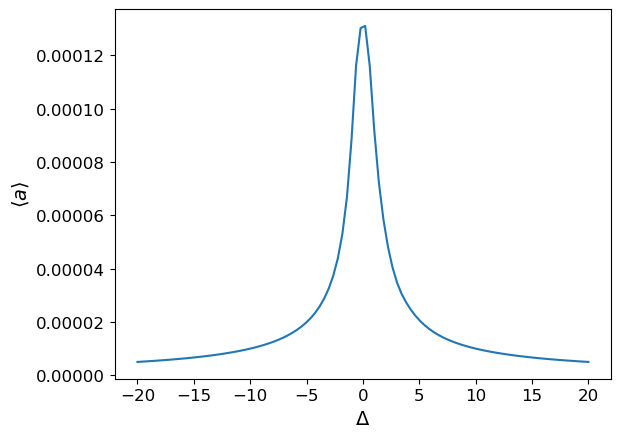

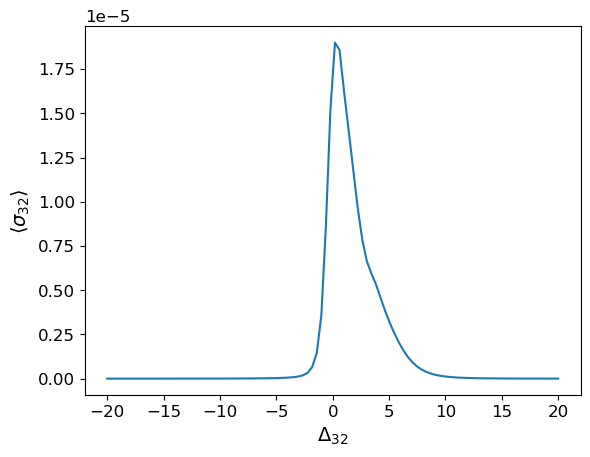

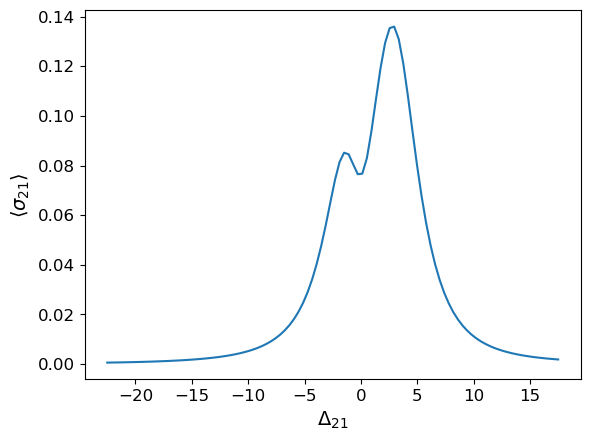

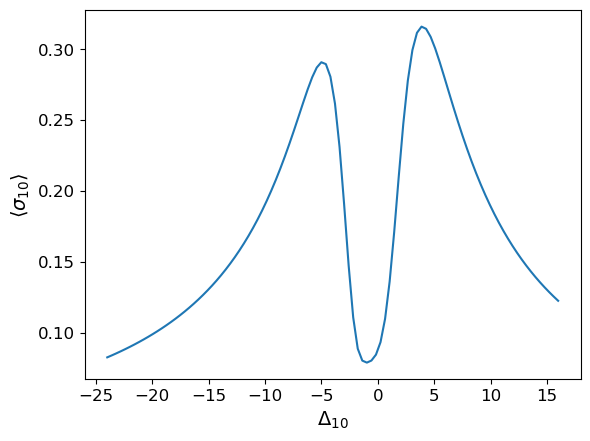

In [17]:
# Plot the expected values of the cavity field against the detuning
plt.figure(1)
plt.plot(ωL32 - ωd, a_expt_list)
#plt.axvline(x=-g, color='k')
#plt.axvline(x=g, color='k')
plt.xlabel("$\\Delta$")
plt.ylabel("$\\langle a \\rangle$")
#plt.legend()

plt.figure(2)
plt.plot(ω32 - ωd, σ32_expt_list)
plt.xlabel("$\\Delta_{32}$")
plt.ylabel("$\\langle \\sigma_{32} \\rangle$")

plt.figure(3)
plt.plot(ω21 - ωd, σ21_expt_list)
plt.xlabel("$\\Delta_{21}$")
plt.ylabel("$\\langle \\sigma_{21} \\rangle$")

plt.figure(4)
plt.plot(ω10 - ωd, σ10_expt_list)
plt.xlabel("$\\Delta_{10}$")
plt.ylabel("$\\langle \\sigma_{10} \\rangle$")